In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost
import shap

print("RiskFusion environment is ready!")


RiskFusion environment is ready!


In [10]:
import pandas as pd

df = pd.read_csv("../data/raw/creditcard.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Shape: (284807, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [11]:
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [13]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [14]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [15]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

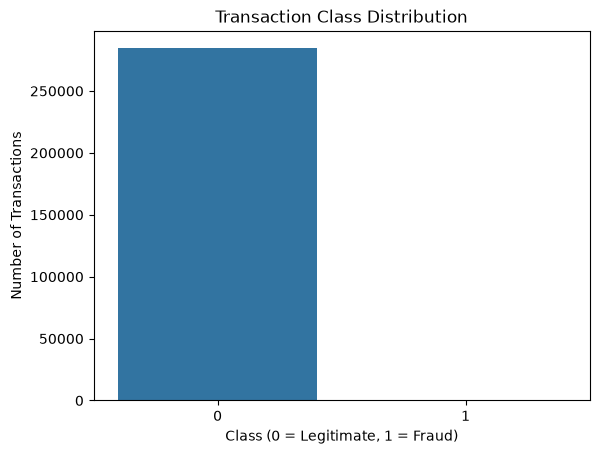

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Class", data=df)

plt.title("Transaction Class Distribution")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

In [17]:
print("Missing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
0

Duplicate rows:
1081


In [18]:
df_clean = df.drop_duplicates().copy()

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Duplicates remaining:", df_clean.duplicated().sum())

Original shape: (284807, 31)
Cleaned shape: (283726, 31)
Duplicates remaining: 0


In [19]:
df_clean["Class"].value_counts()


Class
0    283253
1       473
Name: count, dtype: int64

In [20]:
df_clean["Class"].value_counts(normalize=True) * 100

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

In [21]:
df_clean["Amount"].describe()

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

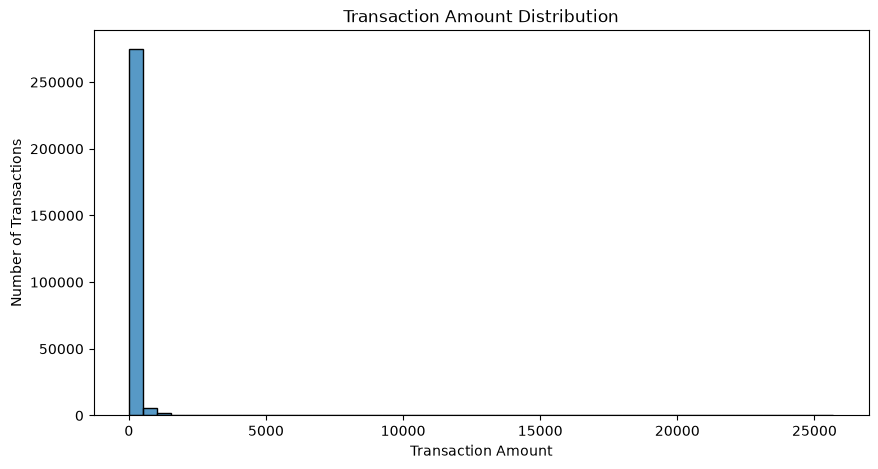

In [22]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_clean,
    x="Amount",
    bins=50
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.show()

In [23]:
df_clean.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


In [24]:
df_clean["Time"].describe()

count    283726.000000
mean      94811.077600
std       47481.047891
min           0.000000
25%       54204.750000
50%       84692.500000
75%      139298.000000
max      172792.000000
Name: Time, dtype: float64

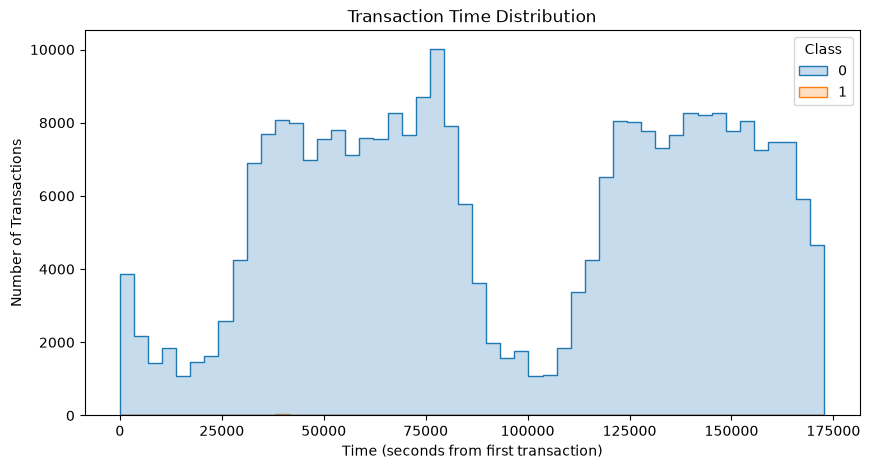

In [25]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_clean,
    x="Time",
    hue="Class",
    bins=50,
    element="step"
)

plt.title("Transaction Time Distribution")
plt.xlabel("Time (seconds from first transaction)")
plt.ylabel("Number of Transactions")

plt.show()

In [26]:
correlations = df_clean.corr(numeric_only=True)["Class"].sort_values()

correlations

V17      -0.313498
V14      -0.293375
V12      -0.250711
V10      -0.206971
V16      -0.187186
V3       -0.182322
V7       -0.172347
V18      -0.105340
V1       -0.094486
V9       -0.094021
V5       -0.087812
V6       -0.043915
Time     -0.012359
V24      -0.007210
V23      -0.006333
V13      -0.003897
V15      -0.003300
V25       0.003202
V26       0.004265
V22       0.004887
Amount    0.005777
V28       0.009682
V20       0.021486
V27       0.021892
V21       0.026357
V8        0.033068
V19       0.033631
V2        0.084624
V4        0.129326
V11       0.149067
Class     1.000000
Name: Class, dtype: float64

In [27]:
correlations.drop("Class").abs().sort_values(ascending=False).head(10)

V17    0.313498
V14    0.293375
V12    0.250711
V10    0.206971
V16    0.187186
V3     0.182322
V7     0.172347
V11    0.149067
V4     0.129326
V18    0.105340
Name: Class, dtype: float64

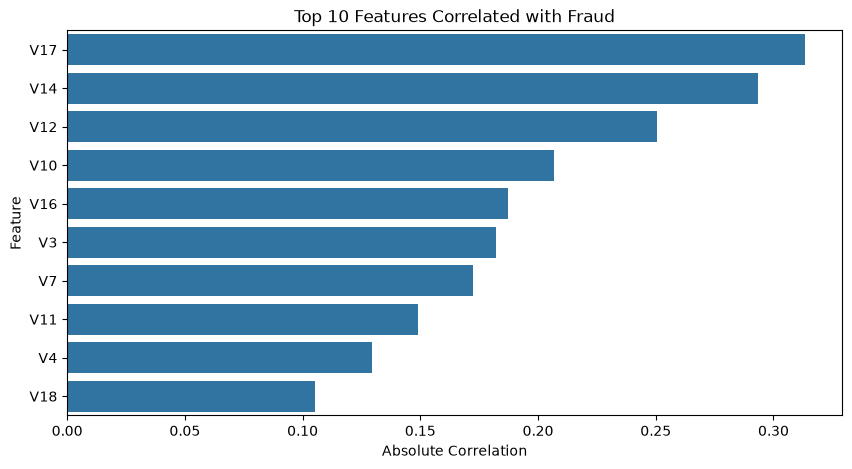

In [28]:
top_corr = correlations.drop("Class").abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title("Top 10 Features Correlated with Fraud")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")

plt.show()

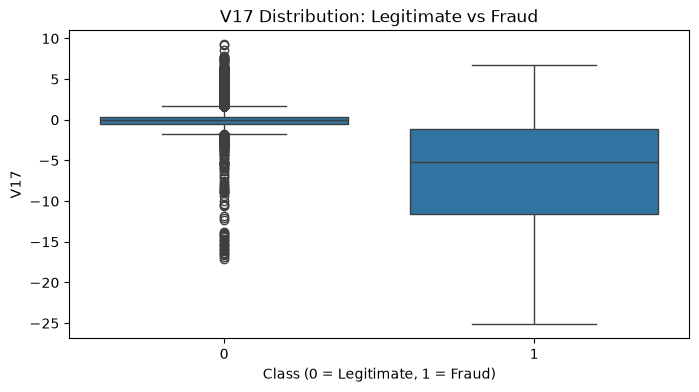

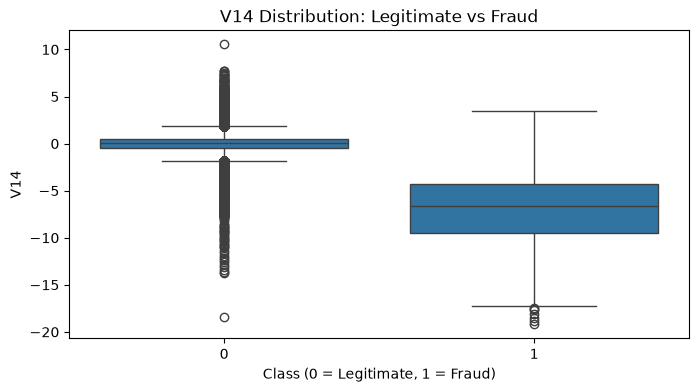

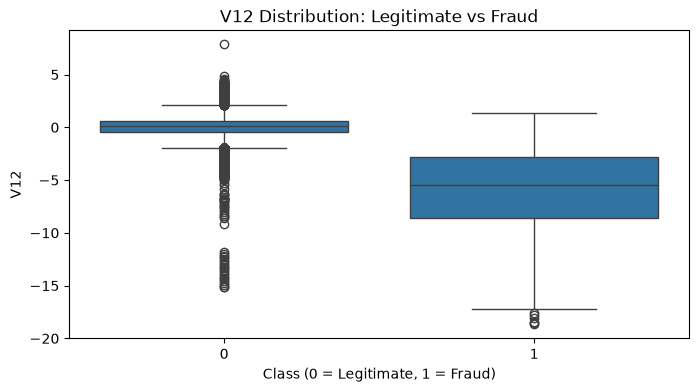

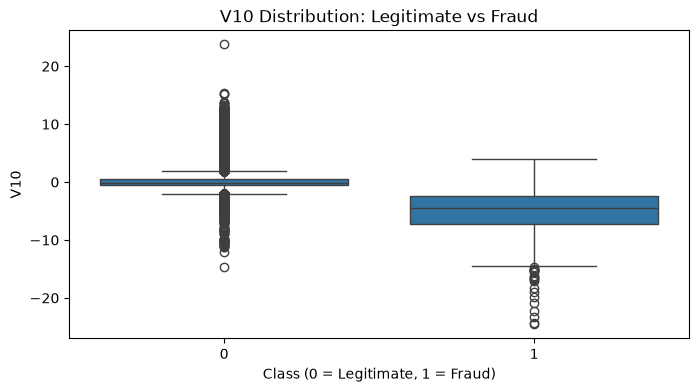

In [29]:
features = ["V17", "V14", "V12", "V10"]

for feature in features:
    plt.figure(figsize=(8, 4))

    sns.boxplot(
        data=df_clean,
        x="Class",
        y=feature
    )

    plt.title(f"{feature} Distribution: Legitimate vs Fraud")
    plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
    plt.ylabel(feature)

    plt.show()

In [30]:
df_clean[["Time", "Amount"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Time,283726.0,94811.077600,47481.047891,0.0,54204.75,84692.5,139298.00,172792.00
Amount,283726.0,88.472687,250.399437,0.0,5.60,22.0,77.51,25691.16


In [31]:
X = df_clean.drop("Class", axis=1)
y = df_clean["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts())

X shape: (283726, 30)
y shape: (283726,)

Class distribution:
Class
0    283253
1       473
Name: count, dtype: int64


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

X_train: (226980, 30)
X_test : (56746, 30)
y_train: (226980,)
y_test : (56746,)

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Testing class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

X_train_scaled shape: (226980, 30)
X_test_scaled shape : (56746, 30)


In [34]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [35]:
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated!")

Predictions generated!


In [36]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix
)

precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
pr_auc_lr = average_precision_score(y_test, y_prob_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(f"Precision : {precision_lr:.4f}")
print(f"Recall    : {recall_lr:.4f}")
print(f"F1 Score  : {f1_lr:.4f}")
print(f"PR-AUC    : {pr_auc_lr:.4f}")

print("\nConfusion Matrix:")
print(cm_lr)

Precision : 0.0564
Recall    : 0.8737
F1 Score  : 0.1059
PR-AUC    : 0.6719

Confusion Matrix:
[[55262  1389]
 [   12    83]]


In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [38]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated!")

Random Forest predictions generated!


In [39]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix
)

precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
pr_auc_rf = average_precision_score(y_test, y_prob_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1 Score  : {f1_rf:.4f}")
print(f"PR-AUC    : {pr_auc_rf:.4f}")

print("\nConfusion Matrix:")
print(cm_rf)

Precision : 0.9583
Recall    : 0.7263
F1 Score  : 0.8263
PR-AUC    : 0.8033

Confusion Matrix:
[[56648     3]
 [   26    69]]


In [40]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [41]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost predictions generated!")

XGBoost predictions generated!


In [42]:
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
pr_auc_xgb = average_precision_score(y_test, y_prob_xgb)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print(f"Precision : {precision_xgb:.4f}")
print(f"Recall    : {recall_xgb:.4f}")
print(f"F1 Score  : {f1_xgb:.4f}")
print(f"PR-AUC    : {pr_auc_xgb:.4f}")

print("\nConfusion Matrix:")
print(cm_xgb)

Precision : 0.9861
Recall    : 0.7474
F1 Score  : 0.8503
PR-AUC    : 0.8273

Confusion Matrix:
[[56650     1]
 [   24    71]]


In [43]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Precision": [precision_lr, precision_rf, precision_xgb],
    "Recall": [recall_lr, recall_rf, recall_xgb],
    "F1 Score": [f1_lr, f1_rf, f1_xgb],
    "PR-AUC": [pr_auc_lr, pr_auc_rf, pr_auc_xgb]
})

results

,Model,Precision,Recall,F1 Score,PR-AUC
0,Logistic Regression,0.056386,0.873684,0.105935,0.671924
1,Random Forest,0.958333,0.726316,0.826347,0.803334
2,XGBoost,0.986111,0.747368,0.850299,0.827338


In [44]:
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print("Training:", X_train_sub.shape)
print("Validation:", X_val.shape)

print("\nValidation class distribution:")
print(y_val.value_counts())

Training: (181584, 30)
Validation: (45396, 30)

Validation class distribution:
Class
0    45320
1       76
Name: count, dtype: int64


In [45]:
# Scale data for Logistic Regression
scaler_ens = StandardScaler()

X_train_sub_scaled = scaler_ens.fit_transform(X_train_sub)
X_val_scaled = scaler_ens.transform(X_val)

# Logistic Regression
lr_ens = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

# Random Forest
rf_ens = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# XGBoost
xgb_ens = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# Train
lr_ens.fit(X_train_sub_scaled, y_train_sub)
rf_ens.fit(X_train_sub, y_train_sub)
xgb_ens.fit(X_train_sub, y_train_sub)

print("All three ensemble models trained successfully!")

All three ensemble models trained successfully!


In [47]:
val_prob_lr = lr_ens.predict_proba(X_val_scaled)[:, 1]
val_prob_rf = rf_ens.predict_proba(X_val)[:, 1]
val_prob_xgb = xgb_ens.predict_proba(X_val)[:, 1]

print("LR :", val_prob_lr.shape)
print("RF :", val_prob_rf.shape)
print("XGB:", val_prob_xgb.shape)

LR : (45396,)
RF : (45396,)
XGB: (45396,)


In [48]:
from scipy.optimize import minimize
from sklearn.metrics import average_precision_score

def ensemble_pr_auc(weights):
    w_lr, w_rf, w_xgb = weights

    ensemble_prob = (
        w_lr * val_prob_lr +
        w_rf * val_prob_rf +
        w_xgb * val_prob_xgb
    )

    return -average_precision_score(y_val, ensemble_prob)


constraints = {
    "type": "eq",
    "fun": lambda w: np.sum(w) - 1
}

bounds = [
    (0, 1),  # Logistic Regression
    (0, 1),  # Random Forest
    (0, 1)   # XGBoost
]

result = minimize(
    ensemble_pr_auc,
    x0=[1/3, 1/3, 1/3],
    bounds=bounds,
    constraints=constraints,
    method="SLSQP"
)

best_weights = result.x

print("Optimized weights:")
print(f"Logistic Regression: {best_weights[0]:.4f}")
print(f"Random Forest:      {best_weights[1]:.4f}")
print(f"XGBoost:            {best_weights[2]:.4f}")

print("\nWeight sum:", best_weights.sum())

best_val_prob = (
    best_weights[0] * val_prob_lr +
    best_weights[1] * val_prob_rf +
    best_weights[2] * val_prob_xgb
)

print("Validation PR-AUC:",
      average_precision_score(y_val, best_val_prob))

Optimized weights:
Logistic Regression: 0.3333
Random Forest:      0.3333
XGBoost:            0.3333

Weight sum: 1.0
Validation PR-AUC: 0.8795513265314557


In [49]:
val_pr_auc_lr = average_precision_score(y_val, val_prob_lr)
val_pr_auc_rf = average_precision_score(y_val, val_prob_rf)
val_pr_auc_xgb = average_precision_score(y_val, val_prob_xgb)
val_pr_auc_ensemble = average_precision_score(y_val, best_val_prob)

print(f"Logistic Regression PR-AUC: {val_pr_auc_lr:.4f}")
print(f"Random Forest PR-AUC:       {val_pr_auc_rf:.4f}")
print(f"XGBoost PR-AUC:             {val_pr_auc_xgb:.4f}")
print(f"RiskFusion Ensemble:        {val_pr_auc_ensemble:.4f}")

Logistic Regression PR-AUC: 0.8139
Random Forest PR-AUC:       0.8714
XGBoost PR-AUC:             0.8783
RiskFusion Ensemble:        0.8796


In [50]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_val,
    best_val_prob
)

print("Number of thresholds:", len(thresholds))
print("First 10 thresholds:", thresholds[:10])

Number of thresholds: 45395
First 10 thresholds: [1.06238227e-07 1.35723638e-07 1.51410591e-07 1.59116264e-07
 1.71619660e-07 1.75998038e-07 1.79307363e-07 1.80712670e-07
 1.92079926e-07 2.03447561e-07]


In [51]:
target_recall = 0.80

valid_indices = np.where(recall[:-1] >= target_recall)[0]

if len(valid_indices) == 0:
    print("No threshold achieves the target recall.")
else:
    # Among thresholds satisfying the recall requirement,
    # choose the one with the highest precision.
    best_idx = valid_indices[np.argmax(precision[:-1][valid_indices])]

    selected_threshold = thresholds[best_idx]

    print(f"Selected threshold: {selected_threshold:.6f}")
    print(f"Precision: {precision[best_idx]:.4f}")
    print(f"Recall:    {recall[best_idx]:.4f}")

Selected threshold: 0.731588
Precision: 0.9846
Recall:    0.8421


In [52]:
# Scale training data for Logistic Regression
scaler_final = StandardScaler()

X_train_final_scaled = scaler_final.fit_transform(X_train)
X_test_final_scaled = scaler_final.transform(X_test)

# Logistic Regression
lr_final = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

# Random Forest
rf_final = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# XGBoost
xgb_final = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# Train on the complete training set
lr_final.fit(X_train_final_scaled, y_train)
rf_final.fit(X_train, y_train)
xgb_final.fit(X_train, y_train)

print("Final ensemble models trained successfully!")

Final ensemble models trained successfully!


In [53]:
test_prob_lr = lr_final.predict_proba(X_test_final_scaled)[:, 1]
test_prob_rf = rf_final.predict_proba(X_test)[:, 1]
test_prob_xgb = xgb_final.predict_proba(X_test)[:, 1]

print("Test probabilities generated!")
print("LR :", test_prob_lr.shape)
print("RF :", test_prob_rf.shape)
print("XGB:", test_prob_xgb.shape)

Test probabilities generated!
LR : (56746,)
RF : (56746,)
XGB: (56746,)


In [54]:
final_test_prob = (
    best_weights[0] * test_prob_lr +
    best_weights[1] * test_prob_rf +
    best_weights[2] * test_prob_xgb
)

print("Final RiskFusion probabilities generated!")
print("Shape:", final_test_prob.shape)
print("Min probability:", final_test_prob.min())
print("Max probability:", final_test_prob.max())

Final RiskFusion probabilities generated!
Shape: (56746,)
Min probability: 1.975689672750466e-07
Max probability: 0.9997576673825581


In [55]:
selected_threshold = 0.731588

final_test_pred = (
    final_test_prob >= selected_threshold
).astype(int)

print("Final predictions generated!")
print("Predicted legitimate:", (final_test_pred == 0).sum())
print("Predicted fraud:", (final_test_pred == 1).sum())

Final predictions generated!
Predicted legitimate: 56675
Predicted fraud: 71


In [56]:
final_precision = precision_score(y_test, final_test_pred)
final_recall = recall_score(y_test, final_test_pred)
final_f1 = f1_score(y_test, final_test_pred)
final_pr_auc = average_precision_score(y_test, final_test_prob)
final_cm = confusion_matrix(y_test, final_test_pred)

print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")
print(f"PR-AUC    : {final_pr_auc:.4f}")

print("\nConfusion Matrix:")
print(final_cm)

Precision : 0.9859
Recall    : 0.7368
F1 Score  : 0.8434
PR-AUC    : 0.8144

Confusion Matrix:
[[56650     1]
 [   25    70]]


In [57]:
from sklearn.metrics import precision_score, recall_score

threshold_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.731588, 0.8, 0.9]

threshold_results = []

for threshold in threshold_values:
    predictions = (final_test_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.100000,0.026535,0.873684,0.051505
1,0.200000,0.077281,0.873684,0.142002
2,0.300000,0.252308,0.863158,0.390476
3,0.400000,0.842697,0.789474,0.815217
4,0.500000,0.935897,0.768421,0.843931
5,0.600000,0.986111,0.747368,0.850299
6,0.700000,0.986111,0.747368,0.850299
7,0.731588,0.985915,0.736842,0.843373
8,0.800000,0.985294,0.705263,0.822086
9,0.900000,0.984615,0.673684,0.800000


In [58]:
import shap

explainer = shap.TreeExplainer(xgb_final)

print("SHAP explainer created!")

SHAP explainer created!


In [59]:
X_test_sample = X_test.iloc[:1000]

shap_values = explainer.shap_values(X_test_sample)

print("SHAP values generated!")
print("Shape:", shap_values.shape)

SHAP values generated!
Shape: (1000, 30)


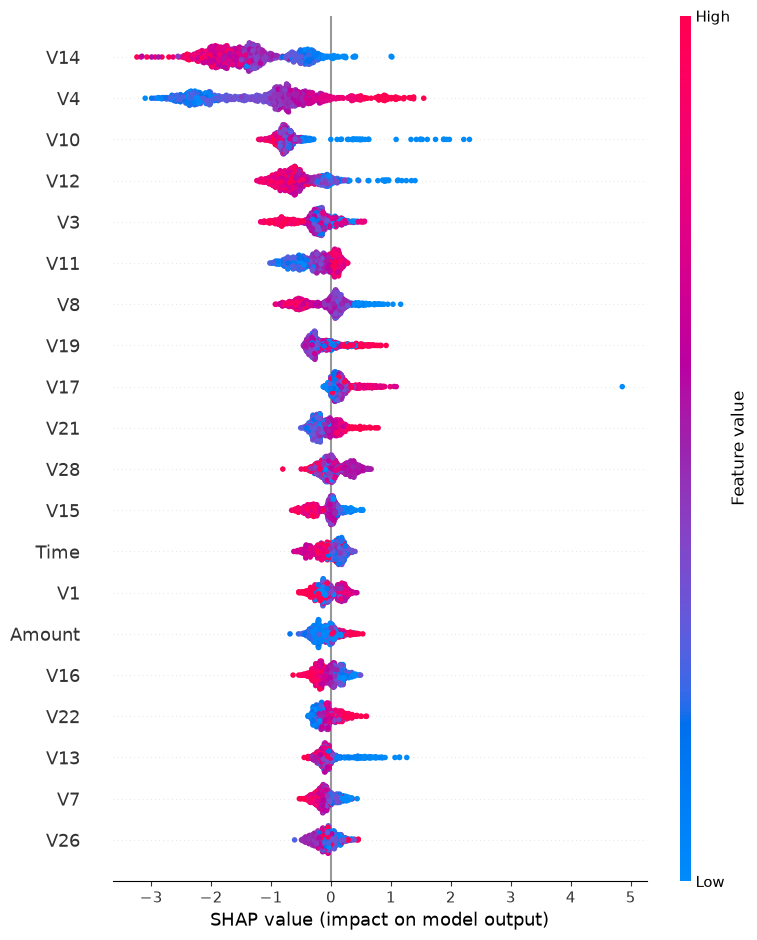

In [60]:
shap.summary_plot(
    shap_values,
    X_test_sample,
    show=True
)

In [61]:
fraud_indices = np.where(final_test_pred == 1)[0]

sample_idx = fraud_indices[0]

sample_transaction = X_test.iloc[[sample_idx]]

print("Test index:", sample_idx)
print("Actual class:", y_test.iloc[sample_idx])
print("RiskFusion probability:", final_test_prob[sample_idx])
print("RiskFusion prediction:", final_test_pred[sample_idx])

Test index: 845
Actual class: 1
RiskFusion probability: 0.9101888878933007
RiskFusion prediction: 1


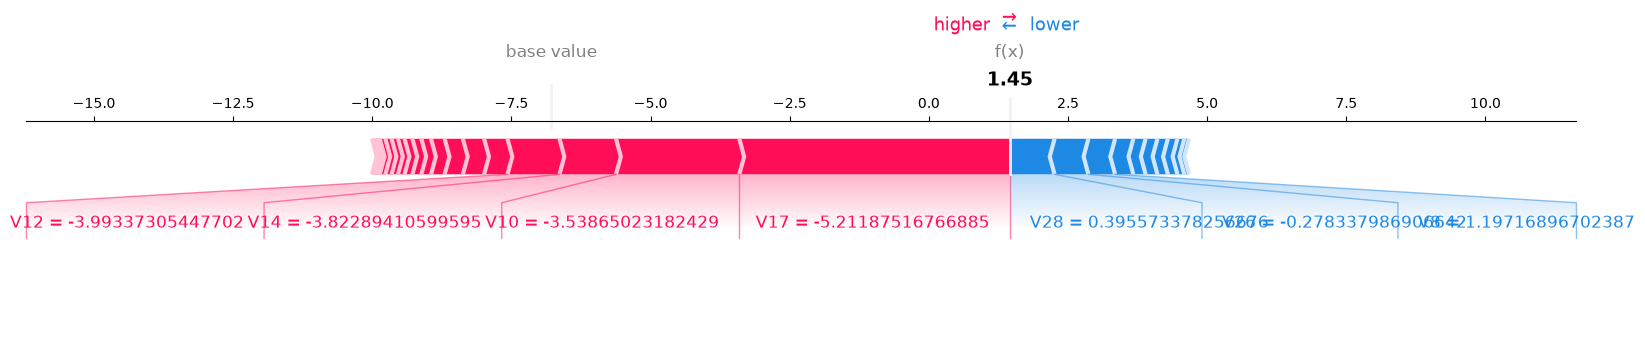

In [62]:
sample_shap_values = explainer.shap_values(sample_transaction)

shap.force_plot(
    explainer.expected_value,
    sample_shap_values[0],
    sample_transaction.iloc[0],
    matplotlib=True
)

plt.show()

In [63]:
feature_contributions = pd.DataFrame({
    "Feature": sample_transaction.columns,
    "SHAP_Value": sample_shap_values[0],
    "Feature_Value": sample_transaction.iloc[0].values
})

feature_contributions["Direction"] = np.where(
    feature_contributions["SHAP_Value"] > 0,
    "Fraud",
    "Legitimate"
)

feature_contributions = feature_contributions.sort_values(
    "SHAP_Value",
    ascending=False
)

feature_contributions

,Feature,SHAP_Value,Feature_Value,Direction
17,V17,4.859109,-5.211875,Fraud
10,V10,2.214933,-3.538650,Fraud
14,V14,1.015554,-3.822894,Fraud
12,V12,0.934172,-3.993373,Fraud
4,V4,0.419566,2.213085,Fraud
13,V13,0.382135,-1.937411,Fraud
7,V7,0.327190,-2.356013,Fraud
16,V16,0.244747,-2.475359,Fraud
0,Time,0.173875,74159.000000,Fraud
27,V27,0.160590,0.625922,Fraud


In [64]:
{
  "fraud_probability": 0.9102,
  "risk_level": "HIGH",
  "prediction": 1,
  "explanation": {
    "fraud_factors": [
      {"feature": "V17", "impact": 4.8591},
      {"feature": "V10", "impact": 2.2149},
      {"feature": "V14", "impact": 1.0156}
    ],
    "legitimate_factors": [
      {"feature": "V28", "impact": -0.8046},
      {"feature": "V26", "impact": -0.6081},
      {"feature": "V8", "impact": -0.4798}
    ]
  }
}

{'fraud_probability': 0.9102,
 'risk_level': 'HIGH',
 'prediction': 1,
 'explanation': {'fraud_factors': [{'feature': 'V17', 'impact': 4.8591},
   {'feature': 'V10', 'impact': 2.2149},
   {'feature': 'V14', 'impact': 1.0156}],
  'legitimate_factors': [{'feature': 'V28', 'impact': -0.8046},
   {'feature': 'V26', 'impact': -0.6081},
   {'feature': 'V8', 'impact': -0.4798}]}}

In [65]:
def predict_riskfusion(transaction):
    """
    transaction: pandas DataFrame containing one transaction
    with the same 30 features used during training.
    """

    # 1. Generate probabilities from all three models
    transaction_scaled = scaler_final.transform(transaction)

    prob_lr = lr_final.predict_proba(transaction_scaled)[:, 1][0]
    prob_rf = rf_final.predict_proba(transaction)[:, 1][0]
    prob_xgb = xgb_final.predict_proba(transaction)[:, 1][0]

    # 2. RiskFusion ensemble probability
    fraud_probability = (
        best_weights[0] * prob_lr +
        best_weights[1] * prob_rf +
        best_weights[2] * prob_xgb
    )

    # 3. Apply selected threshold
    prediction = int(fraud_probability >= selected_threshold)

    # 4. SHAP explanation using XGBoost
    shap_values = explainer.shap_values(transaction)[0]

    explanation = pd.DataFrame({
        "Feature": transaction.columns,
        "SHAP_Value": shap_values,
        "Feature_Value": transaction.iloc[0].values
    })

    explanation["Direction"] = np.where(
        explanation["SHAP_Value"] > 0,
        "Fraud",
        "Legitimate"
    )

    # Strongest contributors in each direction
    fraud_factors = (
        explanation[explanation["SHAP_Value"] > 0]
        .sort_values("SHAP_Value", ascending=False)
        .head(5)
    )

    legitimate_factors = (
        explanation[explanation["SHAP_Value"] < 0]
        .sort_values("SHAP_Value", ascending=True)
        .head(5)
    )

    return {
        "fraud_probability": fraud_probability,
        "prediction": prediction,
        "model_probabilities": {
            "logistic_regression": prob_lr,
            "random_forest": prob_rf,
            "xgboost": prob_xgb
        },
        "fraud_factors": fraud_factors,
        "legitimate_factors": legitimate_factors
    }


print("RiskFusion prediction function created!")

RiskFusion prediction function created!


In [66]:
result = predict_riskfusion(sample_transaction)

print("Fraud probability:",
      f"{result['fraud_probability']:.4f}")

print("Prediction:",
      "Fraud" if result["prediction"] == 1 else "Legitimate")

print("\nModel probabilities:")
for model, prob in result["model_probabilities"].items():
    print(f"{model}: {prob:.4f}")

print("\nTop fraud factors:")
print(result["fraud_factors"][["Feature", "SHAP_Value", "Feature_Value"]])

print("\nTop legitimate factors:")
print(result["legitimate_factors"][["Feature", "SHAP_Value", "Feature_Value"]])

Fraud probability: 0.9102
Prediction: Fraud

Model probabilities:
logistic_regression: 1.0000
random_forest: 0.9200
xgboost: 0.8106

Top fraud factors:
   Feature  SHAP_Value  Feature_Value
17     V17    4.859109      -5.211875
10     V10    2.214933      -3.538650
14     V14    1.015554      -3.822894
12     V12    0.934172      -3.993373
4       V4    0.419566       2.213085

Top legitimate factors:
   Feature  SHAP_Value  Feature_Value
28     V28   -0.804641       0.395573
26     V26   -0.608145      -0.278338
8       V8   -0.479765       1.197169
29  Amount   -0.327107      76.940000
2       V2   -0.220982       1.808698


In [67]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(lr_final, "../models/logistic_regression.pkl")
joblib.dump(rf_final, "../models/random_forest.pkl")
joblib.dump(xgb_final, "../models/xgboost.pkl")

joblib.dump(scaler_final, "../models/scaler.pkl")
joblib.dump(explainer, "../models/shap_explainer.pkl")

joblib.dump(best_weights, "../models/ensemble_weights.pkl")
joblib.dump(selected_threshold, "../models/threshold.pkl")

print("All RiskFusion artifacts saved successfully!")

All RiskFusion artifacts saved successfully!


In [68]:
import os

for filename in os.listdir("../models"):
    print(filename)

ensemble_weights.pkl
logistic_regression.pkl
random_forest.pkl
scaler.pkl
shap_explainer.pkl
threshold.pkl
xgboost.pkl


In [69]:
sample_transaction.to_dict(orient="records")[0]

{'Time': 74159.0,
 'V1': -1.54878809850026,
 'V2': 1.80869795041448,
 'V3': -0.953509033832342,
 'V4': 2.21308539346999,
 'V5': -2.01572779170327,
 'V6': -0.913456844516923,
 'V7': -2.35601298316433,
 'V8': 1.19716896702387,
 'V9': -1.67837405659509,
 'V10': -3.53865023182429,
 'V11': 3.1020899271543,
 'V12': -3.99337305447702,
 'V13': -1.93741062327519,
 'V14': -3.82289410599595,
 'V15': 0.830970110708369,
 'V16': -2.47535885382925,
 'V17': -5.21187516766885,
 'V18': -0.413871678166879,
 'V19': 0.933262164554872,
 'V20': 0.390785963777347,
 'V21': 0.855138263312025,
 'V22': 0.77474482148342,
 'V23': 0.0590371520063436,
 'V24': 0.343199807900813,
 'V25': -0.468937928609185,
 'V26': -0.278337986906642,
 'V27': 0.625922215184372,
 'V28': 0.395573378256676,
 'Amount': 76.94}